In [ ]:
import pandas as pd
df=pd.read_csv('/content/student_academic_performance.csv')

In [ ]:
df.head()


,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access
0,1,female,group B,some college,standard,False,12.4,5.4,62.0,76.0,65.0,public,True
1,2,male,group D,high school,standard,False,18.3,5.1,74.0,73.0,76.0,public,NaN
2,3,male,group B,bachelor degree,free/reduced,True,11.8,7.8,71.0,83.0,91.0,public,False
3,4,male,group E,high school,standard,False,NaN,7.3,83.0,73.0,52.0,public,True
4,5,female,group C,bachelor degree,standard,True,12.9,6.3,41.0,NaN,81.0,public,True


In [ ]:
df.shape

(7000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student ID            7000 non-null   int64  
 1   Gender                7000 non-null   object 
 2   Race/Ethnicity        7000 non-null   object 
 3   Parental Education    6300 non-null   object 
 4   Lunch Type            6790 non-null   object 
 5   Test Preparation      7000 non-null   bool   
 6   Study Time per Week   6370 non-null   float64
 7   Daily Sleep Duration  6440 non-null   float64
 8   Math Score            7000 non-null   float64
 9   Reading Score         6510 non-null   float64
 10  Writing Score         6650 non-null   float64
 11  School Type           7000 non-null   object 
 12  Internet Access       6720 non-null   object 
dtypes: bool(1), float64(5), int64(1), object(6)
memory usage: 663.2+ KB


In [ ]:
df.isnull().sum()


,0
Student ID,0
Gender,0
Race/Ethnicity,0
Parental Education,700
Lunch Type,210
Test Preparation,0
Study Time per Week,630
Daily Sleep Duration,560
Math Score,0
Reading Score,490


In [ ]:
df = df.fillna(df.mode().iloc[0])
df.isnull().sum()


/tmp/ipykernel_816/2541136416.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(df.mode().iloc[0])


,0
Student ID,0
Gender,0
Race/Ethnicity,0
Parental Education,0
Lunch Type,0
Test Preparation,0
Study Time per Week,0
Daily Sleep Duration,0
Math Score,0
Reading Score,0


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.describe()

,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,8.793014,7.202100,69.476571,71.194714,70.487429
std,2020.870275,5.253145,1.263536,14.782909,13.327615,13.352877
min,1.000000,0.000000,3.000000,3.000000,21.000000,14.000000
25%,1750.750000,5.200000,6.400000,59.000000,63.000000,62.000000
50%,3500.500000,9.000000,7.300000,70.000000,72.000000,71.000000
75%,5250.250000,12.400000,8.000000,80.000000,80.000000,79.000000
max,7000.000000,26.100000,11.000000,100.000000,100.000000,100.000000


In [ ]:
df.select_dtypes('number').agg(['mean','median','std','var'])

,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
mean,3.500500e+03,8.793014,7.202100,69.476571,71.194714,70.487429
median,3.500500e+03,9.000000,7.300000,70.000000,72.000000,71.000000
std,2.020870e+03,5.253145,1.263536,14.782909,13.327615,13.352877
var,4.083917e+06,27.595535,1.596522,218.534385,177.625319,178.299313


In [ ]:
df.select_dtypes('number').mode().iloc[0]


,0
Student ID,1.0
Study Time per Week,0.0
Daily Sleep Duration,7.3
Math Score,73.0
Reading Score,72.0
Writing Score,71.0


In [ ]:
Q1=df.select_dtypes('number').quantile(0.25)
Q3=df.select_dtypes('number').quantile(0.75)
IQR=Q3-Q1
((df.select_dtypes('number')<Q1-1.5*IQR)|(df.select_dtypes('number')>Q3+1.5*IQR)).sum()

,0
Student ID,0
Study Time per Week,8
Daily Sleep Duration,107
Math Score,23
Reading Score,58
Writing Score,50


In [ ]:
num=df.select_dtypes('number')
Q1=num.quantile(.25)
Q3=num.quantile(.75)
IQR=Q3-Q1
df[num.columns]=num.clip(Q1-IQR,Q3+1.5*IQR,axis=1)
num.head()



,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
0,1,12.4,5.4,62.0,76.0,65.0
1,2,18.3,5.1,74.0,73.0,76.0
2,3,11.8,7.8,71.0,83.0,91.0
3,4,0.0,7.3,83.0,73.0,52.0
4,5,12.9,6.3,41.0,72.0,81.0


In [ ]:
df.describe()

,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,8.791071,7.216529,69.575143,71.394714,70.661000
std,2020.870275,5.247439,1.219170,14.532386,12.861525,12.946418
min,1.000000,0.000000,4.800000,38.000000,46.000000,45.000000
25%,1750.750000,5.200000,6.400000,59.000000,63.000000,62.000000
50%,3500.500000,9.000000,7.300000,70.000000,72.000000,71.000000
75%,5250.250000,12.400000,8.000000,80.000000,80.000000,79.000000
max,7000.000000,23.200000,10.400000,100.000000,100.000000,100.000000


In [ ]:
df.select_dtypes('object').nunique()

,0
Gender,2
Race/Ethnicity,5
Parental Education,5
Lunch Type,2
School Type,3


In [ ]:
df.select_dtypes('object').apply(lambda x:x.value_counts())

,Gender,Race/Ethnicity,Parental Education,Lunch Type,School Type
associate degree,NaN,NaN,1101.0,NaN,NaN
bachelor degree,NaN,NaN,1262.0,NaN,NaN
female,3539.0,NaN,NaN,NaN,NaN
free/reduced,NaN,NaN,NaN,2251.0,NaN
group A,NaN,996.0,NaN,NaN,NaN
group B,NaN,1482.0,NaN,NaN,NaN
group C,NaN,1820.0,NaN,NaN,NaN
group D,NaN,1297.0,NaN,NaN,NaN
group E,NaN,1405.0,NaN,NaN,NaN
high school,NaN,NaN,2545.0,NaN,NaN


In [ ]:
df.select_dtypes('object').describe()

,Gender,Race/Ethnicity,Parental Education,Lunch Type,School Type
count,7000,7000,7000,7000,7000
unique,2,5,5,2,3
top,female,group C,high school,standard,public
freq,3539,1820,2545,4749,4837


In [ ]:
df.select_dtypes('object').describe()

,Gender,Race/Ethnicity,Parental Education,Lunch Type,School Type
count,7000,7000,7000,7000,7000
unique,2,5,5,2,3
top,female,group C,high school,standard,public
freq,3539,1820,2545,4749,4837


In [ ]:
for c in df.select_dtypes('object'):print(c,df[c].value_counts().to_dict())

Gender {'female': 3539, 'male': 3461}
Race/Ethnicity {'group C': 1820, 'group B': 1482, 'group E': 1405, 'group D': 1297, 'group A': 996}
Parental Education {'high school': 2545, 'some college': 1498, 'bachelor degree': 1262, 'associate degree': 1101, 'master degree': 594}
Lunch Type {'standard': 4749, 'free/reduced': 2251}
School Type {'public': 4837, 'private': 1480, 'international': 683}


In [ ]:
corr=df.select_dtypes('number').corr()
corr

,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
Student ID,1.000000,0.007335,-0.002685,-0.002967,0.016211,0.008474
Study Time per Week,0.007335,1.000000,-0.011835,0.014621,-0.006393,-0.012565
Daily Sleep Duration,-0.002685,-0.011835,1.000000,-0.013569,0.004284,-0.006413
Math Score,-0.002967,0.014621,-0.013569,1.000000,0.005577,-0.005888
Reading Score,0.016211,-0.006393,0.004284,0.005577,1.000000,0.011182
Writing Score,0.008474,-0.012565,-0.006413,-0.005888,0.011182,1.000000


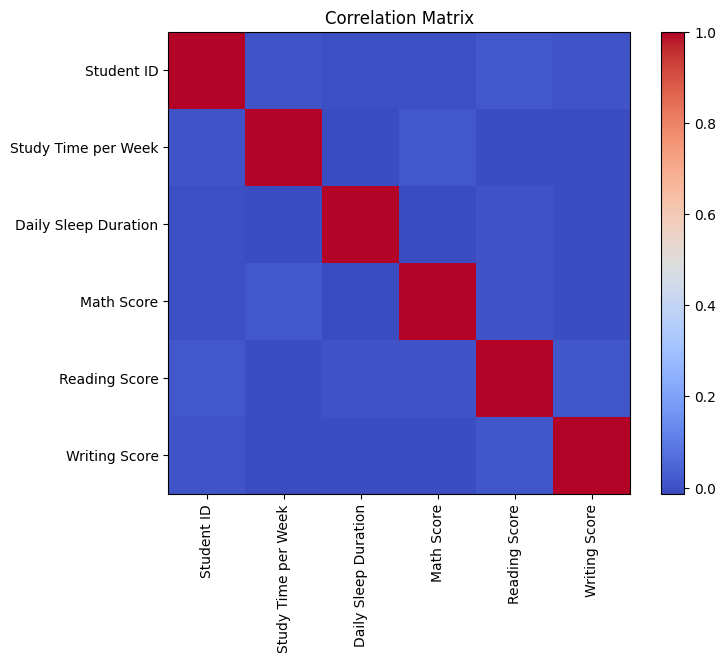

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.imshow(df.select_dtypes('number').corr(),cmap='coolwarm')
plt.colorbar()
plt.xticks(range(6),df.select_dtypes('number').columns,rotation=90)
plt.yticks(range(6),df.select_dtypes('number').columns)
plt.title('Correlation Matrix')
plt.show()


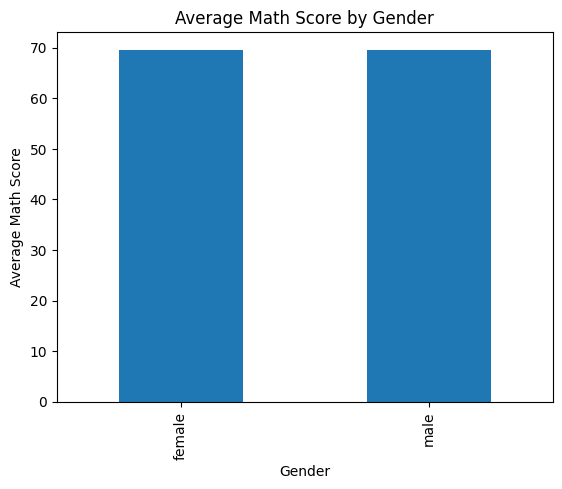

In [ ]:
df.groupby('Gender')['Math Score'].mean().plot(kind='bar')
plt.title('Average Math Score by Gender')
plt.ylabel('Average Math Score')
plt.show()

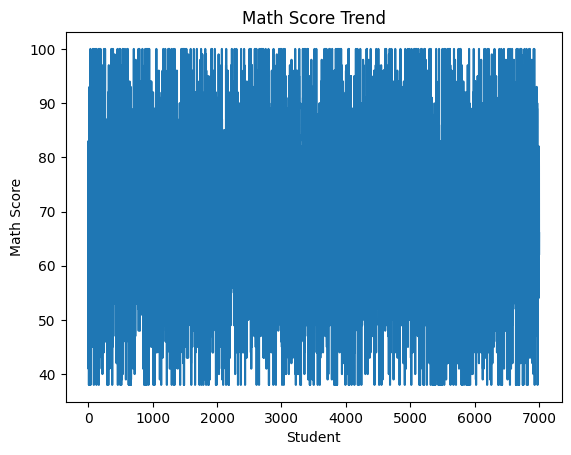

In [ ]:
plt.plot(df['Math Score'])
plt.title('Math Score Trend')
plt.xlabel('Student')
plt.ylabel('Math Score')
plt.show()

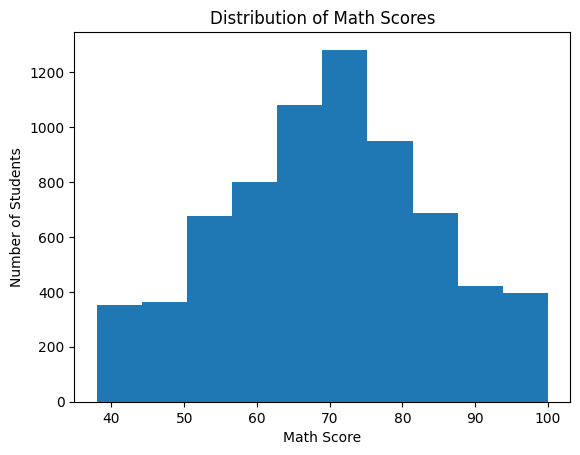

In [ ]:
plt.hist(df['Math Score'],bins=10)
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.show()

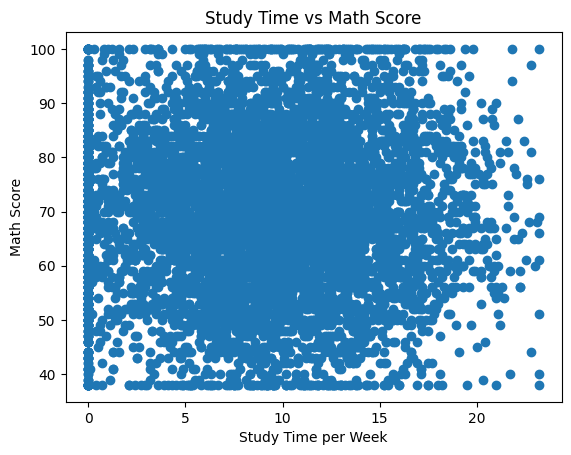

In [ ]:
plt.scatter(df['Study Time per Week'],
            df['Math Score'])
plt.title('Study Time vs Math Score')
plt.xlabel('Study Time per Week')
plt.ylabel('Math Score')
plt.show()

EDA Summary:
 Student Performance Analysis
The dataset contains student information and their exam scores.
Missing values and duplicate records were checked and handled.
Descriptive statistics such as mean, median, mode, variance, and standard deviation were calculated.
Outliers were detected using the IQR method and treated.
Correlation analysis was performed to understand relationships between numerical variables.
Bar, line, histogram, and scatter plots were created to visualize the data.
The analysis helps understand student performance and the relationship between different academic scores.
Overall, the EDA provides useful insights into factors associated with student exam performance.